# Meteo Colombia

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [60]:
path = 'meteo_colombia/'
files = os.listdir(path)
files

['barranquilla.xlsx',
 'bogota.xlsx',
 'bucaramanga.xlsx',
 'cali.xlsx',
 'cartagena.xlsx',
 'manizales.xlsx',
 'medellin.xlsx']

In [61]:
df = pd.read_excel(path + files[0])

In [62]:
df.head()

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2020-01-01 00:00:00,28.2,25.9,32.5,0.0,NaN,9,17.0,NaN,1010.5,NaN
1,2020-01-02 00:00:00,27.9,25.0,33.3,0.0,NaN,14,15.7,NaN,1010.9,NaN
2,2020-01-03 00:00:00,27.9,23.4,32.2,0.0,NaN,6,13.9,NaN,1012.2,NaN
3,2020-01-04 00:00:00,27.9,23.0,33.1,0.0,NaN,15,13.3,NaN,1013.3,NaN
4,2020-01-05 00:00:00,27.8,25.8,33.1,0.0,NaN,6,22.9,NaN,1014.1,NaN


In [63]:
df.columns

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt',
       'pres', 'tsun'],
      dtype='object')

In [64]:
df = df[['date', 'tavg', 'tmin', 'tmax', 'prcp',  'wdir', 'wspd', 'pres']]

In [65]:
df['date'] = pd.to_datetime(df['date'])

In [66]:
df.describe()

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,1827,1827.000000,1827.000000,1827.000000,1300.000000,1827.000000,1827.000000,1827.000000
mean,2022-07-02 00:00:00.000000256,27.900328,24.791735,32.514724,1.688154,86.016420,12.221730,1009.830378
min,2020-01-01 00:00:00,23.600000,16.000000,25.000000,0.000000,0.000000,3.900000,1005.700000
25%,2021-04-01 12:00:00,27.200000,24.000000,31.700000,0.000000,27.000000,8.400000,1008.900000
50%,2022-07-02 00:00:00,27.800000,25.000000,32.500000,0.000000,37.000000,11.200000,1009.800000
75%,2023-10-01 12:00:00,28.600000,25.800000,33.400000,0.000000,89.000000,15.000000,1010.700000
max,2024-12-31 00:00:00,31.200000,28.000000,39.000000,53.000000,359.000000,29.500000,1014.100000
std,NaN,1.078979,1.211230,1.542426,5.265122,100.593146,4.859649,1.318689


# Paste them all

In [67]:
dataframes = []
vars_to_keep = ['date', 'tavg', 'tmin', 'tmax', 'prcp',  'wdir', 'wspd', 'pres']
for file in files:
    city = file.split('.')[0]
    df_temp = pd.read_excel(path + file)
    df_temp = df_temp[vars_to_keep]
    df_temp['city'] = city
    dataframes.append(df_temp)

df_final = pd.concat(dataframes, ignore_index = True)



In [68]:
df_final

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,city
0,2020-01-01 00:00:00,28.2,25.9,32.5,0.0,9.0,17.0,1010.5,barranquilla
1,2020-01-02 00:00:00,27.9,25.0,33.3,0.0,14.0,15.7,1010.9,barranquilla
2,2020-01-03 00:00:00,27.9,23.4,32.2,0.0,6.0,13.9,1012.2,barranquilla
3,2020-01-04 00:00:00,27.9,23.0,33.1,0.0,15.0,13.3,1013.3,barranquilla
4,2020-01-05 00:00:00,27.8,25.8,33.1,0.0,6.0,22.9,1014.1,barranquilla
...,...,...,...,...,...,...,...,...,...
12784,2024-12-27 00:00:00,19.8,16.6,24.0,9.8,112.0,6.1,1019.6,medellin
12785,2024-12-28 00:00:00,20.5,15.4,26.0,14.9,109.0,8.4,NaN,medellin
12786,2024-12-29 00:00:00,20.4,14.3,28.0,7.4,108.0,9.5,NaN,medellin
12787,2024-12-30 00:00:00,18.6,14.6,24.0,13.6,212.0,6.4,NaN,medellin


<Axes: xlabel='date', ylabel='prcp'>

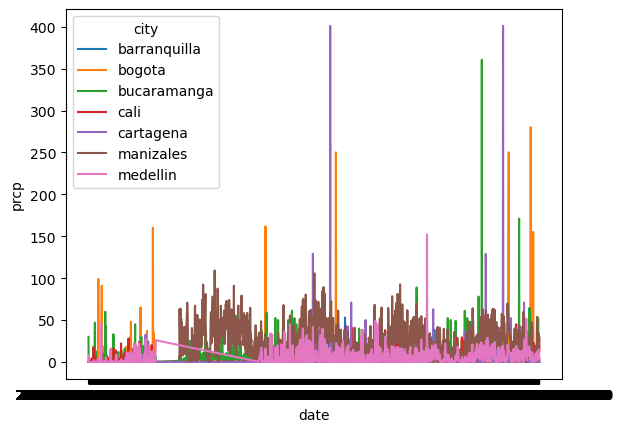

In [69]:
sns.lineplot(data = df_final, x = 'date', y = 'prcp', hue='city')

In [70]:
# fill nans
# first interpolate, then ffill then bfill
for col in vars_to_keep:
    df_final[col] = df_final.groupby('city')[col].transform(
        lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
    )


C:\Users\danie\AppData\Local\Temp\ipykernel_13260\3216786931.py:5: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
C:\Users\danie\AppData\Local\Temp\ipykernel_13260\3216786931.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
C:\Users\danie\AppData\Local\Temp\ipykernel_13260\3216786931.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
C:\Users\danie\AppData\Local\Temp\ipykernel_13260\3216786931.py:5: FutureWarning: Series.fillna wit

In [71]:
df_final.isna().any()

date    False
tavg    False
tmin    False
tmax    False
prcp    False
wdir    False
wspd    False
pres    False
city    False
dtype: bool

# Weighted Averages

In [72]:
import re
from unidecode import unidecode
# function to clean data
def clean_data(df, col, clean_col):

    # change to lower and remove spaces on either side
    df[clean_col] = df[col].apply(lambda x: x.lower().strip())

    # remove extra spaces in between
    df[clean_col] = df[clean_col].apply(lambda x: re.sub(' +', ' ', x))

    # remove accents
    df[clean_col] = df[clean_col].apply(lambda x: unidecode(x))
    
    return df


In [73]:
df_pop = pd.read_excel('colombia/population_dane_2023.xlsx')
df_pop['city'] = df_pop['city']

In [74]:
df_pop_clean = clean_data(df_pop, 'city', 'city_clean')
df_pop_clean

,city,population,city_clean
0,Bogotá,7968095,bogota
1,Medellín,2653729,medellin
2,Cali,2297230,cali
3,Barranquilla,1327209,barranquilla
4,Cartagena,1065570,cartagena
5,Soacha,831259,soacha
6,Cúcuta,795608,cucuta
7,Soledad,692799,soledad
8,Bucaramanga,623378,bucaramanga
9,Bello,578376,bello


In [75]:
cities = []
for file in files:
    city = file.split('.')[0]
    cities.append(city)

In [76]:
df_pop_filtered = df_pop_clean[df_pop_clean['city_clean'].isin(cities)]
df_pop_filtered['pct_city'] = df_pop_filtered['population'] / df_pop_filtered['population'].sum()
df_pop_filtered


C:\Users\danie\AppData\Local\Temp\ipykernel_13260\441196448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pop_filtered['pct_city'] = df_pop_filtered['population'] / df_pop_filtered['population'].sum()


,city,population,city_clean,pct_city
0,Bogotá,7968095,bogota,0.486048
1,Medellín,2653729,medellin,0.161875
2,Cali,2297230,cali,0.140129
3,Barranquilla,1327209,barranquilla,0.080959
4,Cartagena,1065570,cartagena,0.064999
8,Bucaramanga,623378,bucaramanga,0.038026
16,Manizales,458442,manizales,0.027965


In [77]:
df_pop_small = df_pop_filtered[['city_clean', 'pct_city']].copy()
df_pop_small.columns = ['city', 'pct']
df_pop_small


,city,pct
0,bogota,0.486048
1,medellin,0.161875
2,cali,0.140129
3,barranquilla,0.080959
4,cartagena,0.064999
8,bucaramanga,0.038026
16,manizales,0.027965


# Merge

In [78]:
df_merge = df_final.merge(df_pop_small, how = 'left', on = 'city')
df_merge

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,city,pct
0,2020-01-01 00:00:00,28.2,25.9,32.5,0.0,9.0,17.0,1010.5,barranquilla,0.080959
1,2020-01-02 00:00:00,27.9,25.0,33.3,0.0,14.0,15.7,1010.9,barranquilla,0.080959
2,2020-01-03 00:00:00,27.9,23.4,32.2,0.0,6.0,13.9,1012.2,barranquilla,0.080959
3,2020-01-04 00:00:00,27.9,23.0,33.1,0.0,15.0,13.3,1013.3,barranquilla,0.080959
4,2020-01-05 00:00:00,27.8,25.8,33.1,0.0,6.0,22.9,1014.1,barranquilla,0.080959
...,...,...,...,...,...,...,...,...,...,...
12784,2024-12-27 00:00:00,19.8,16.6,24.0,9.8,112.0,6.1,1019.6,medellin,0.161875
12785,2024-12-28 00:00:00,20.5,15.4,26.0,14.9,109.0,8.4,1019.6,medellin,0.161875
12786,2024-12-29 00:00:00,20.4,14.3,28.0,7.4,108.0,9.5,1019.6,medellin,0.161875
12787,2024-12-30 00:00:00,18.6,14.6,24.0,13.6,212.0,6.4,1019.6,medellin,0.161875


In [79]:
df_og = df_merge.copy()

In [80]:
df_merge.columns

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'city',
       'pct'],
      dtype='object')

In [81]:
# weight each 
cols_transform = ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
for col in cols_transform:
    df_merge[col] = df_merge[col] * df_merge['pct']

In [83]:
# groupby
df_group = df_merge.groupby(['date'])[['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']].sum().reset_index()
df_group.head()

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2020-01-01 00:00:00,19.134580,13.762969,25.597902,4.161777,207.669684,9.821321,1014.641533
1,2020-01-02 00:00:00,19.994038,13.436560,26.333776,1.742195,214.298516,9.480171,1014.825193
2,2020-01-03 00:00:00,19.911814,13.367846,26.725776,1.742195,173.844417,8.866631,1016.253415
3,2020-01-04 00:00:00,18.927883,12.050856,26.621747,1.742195,165.074104,9.160440,1017.131956
4,2020-01-05 00:00:00,19.283571,12.440939,26.316475,1.742195,211.269126,11.285519,1017.696583


In [84]:
df_group.describe()

,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000
mean,19.193545,14.309711,24.790587,4.685954,141.262918,9.331566,1019.099370
std,0.836094,1.188293,1.232365,7.433292,80.247825,1.486498,2.431616
min,16.686868,9.273177,19.928438,0.005593,9.963259,5.667626,1011.453884
25%,18.592762,13.696045,23.995558,1.898100,68.193953,8.234726,1018.520203
50%,19.150928,14.480020,24.784983,3.295226,116.081203,9.173898,1019.858990
75%,19.760814,15.094629,25.619461,5.550141,216.164386,10.242577,1020.748367
max,21.995347,17.423732,29.720723,141.592924,338.895620,15.256852,1023.487041


In [90]:
df_group['date'] = pd.to_datetime(df_group['date'])

In [91]:
import datetime as dt
# groupby week
df_group['week'] = df_group['date'].dt.to_period('W').dt.to_timestamp()
df_group

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,week
0,2020-01-01,19.134580,13.762969,25.597902,4.161777,207.669684,9.821321,1014.641533,2019-12-30
1,2020-01-02,19.994038,13.436560,26.333776,1.742195,214.298516,9.480171,1014.825193,2019-12-30
2,2020-01-03,19.911814,13.367846,26.725776,1.742195,173.844417,8.866631,1016.253415,2019-12-30
3,2020-01-04,18.927883,12.050856,26.621747,1.742195,165.074104,9.160440,1017.131956,2019-12-30
4,2020-01-05,19.283571,12.440939,26.316475,1.742195,211.269126,11.285519,1017.696583,2019-12-30
...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,18.428546,14.331703,24.303403,4.592431,218.325776,8.792527,1020.566736,2024-12-23
1823,2024-12-28,18.712201,15.002359,23.808201,6.434040,205.303085,8.704755,1020.954695,2024-12-23
1824,2024-12-29,19.095944,15.489761,25.073689,2.145878,209.732868,9.156160,1021.141534,2024-12-23
1825,2024-12-30,18.154777,15.210448,22.618123,7.362242,271.164886,7.399502,1020.371713,2024-12-30


In [96]:
df_week = df_group.groupby(['week'])[['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']].mean().reset_index()
df_week.rename(columns={'week': 'date'}, inplace=True)
df_week

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2019-12-30,19.450377,13.011834,26.319135,2.226111,194.431169,9.722817,1016.109736
1,2020-01-06,19.083392,11.511172,26.336976,1.757209,119.680480,11.313645,1014.248141
2,2020-01-13,20.013624,14.086101,26.512647,1.824270,70.500326,12.548239,1012.854773
3,2020-01-20,19.412924,14.504582,25.324612,2.991630,218.793642,9.854209,1015.718609
4,2020-01-27,19.669235,13.603087,25.948477,2.780497,143.062092,10.089568,1015.457101
...,...,...,...,...,...,...,...,...
257,2024-12-02,19.036163,13.892360,25.848276,12.784247,197.195154,9.545047,1019.568423
258,2024-12-09,18.865067,13.703137,24.861928,1.509092,154.496745,10.646646,1019.122945
259,2024-12-16,19.325119,14.351254,25.818360,2.476637,76.178666,9.419621,1020.754290
260,2024-12-23,18.979642,14.954641,24.802459,4.109291,211.905768,8.708465,1020.728056


In [97]:
df_week.to_csv('silver/meteo_colombia.csv', index=False)